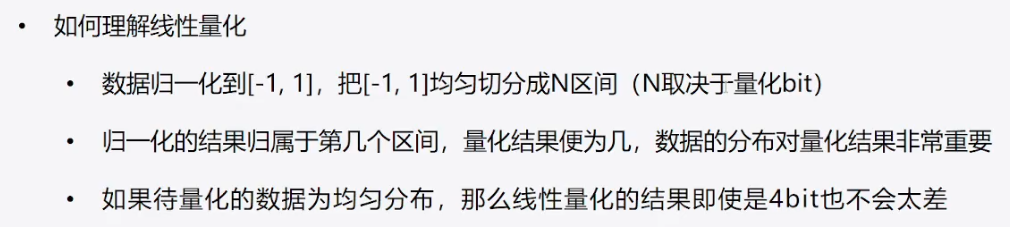

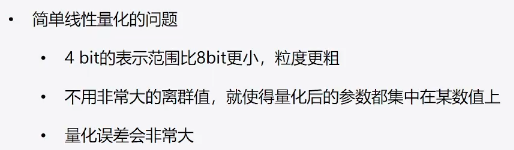

所以对于数据是均匀分布的情况，用线性量化效果会比较好，但是对于非均匀分布的情况，线性量化效果可能不好。而模型参数是正态分布的。

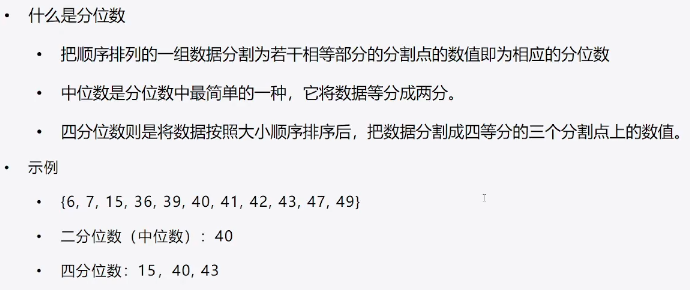

可以这样想象，{6, 7, 15, 36, 39, 40, 41, 42, 43, 47, 49}就是所有模型权重（如果是二维的就转换成一维的），15, 40, 43这三个权重把所有权重四等分，这3个权重值就是所有模型权重的四分位数。

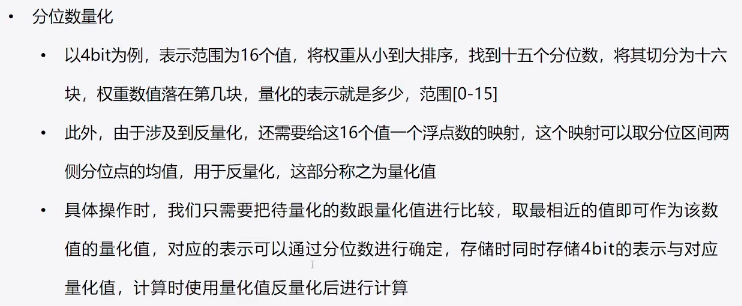  

INT4量化时，可以这样想象，把所有权重拉平成一维的，将这个一维数组平分成16份，找到的15个权重值即模型权重的16分位数。  

然后，对于每一个权重值，属于哪个区间，其量化值就是几，范围是[0, 15]。例如，一个权重属于第5区间，其量化值就是5；

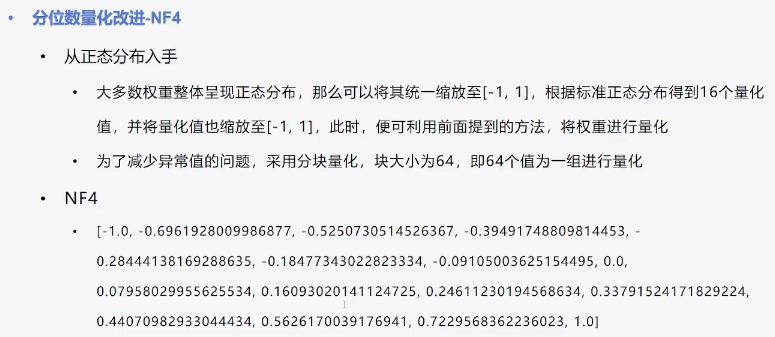

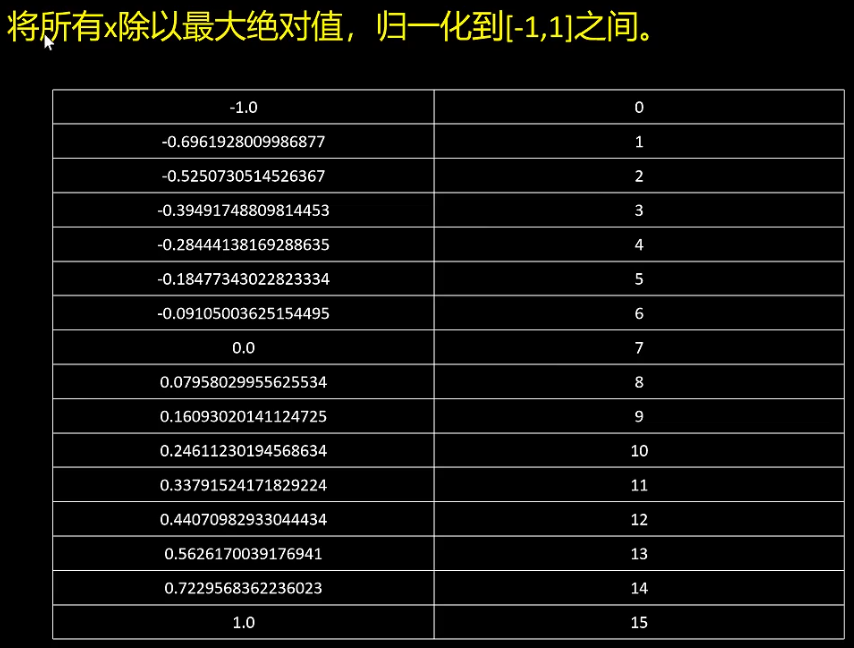

# NF4是4-bit NormalFloat的缩写  

权重分布属于正态分布，将所有正态分布的权重归一化到[-1, 1]之间，上面的表格的左侧即“正态分布情况下”，权重的16分位数。注意，只有在“正态分布情况下”，16分位数才是这些值，其他分布不是这些值。  
表格右侧的整数[0, 15]，即权重的量化值。  

注意：  
为了减少异常值，采用分块量化，每块大小为64，即每64个权重为一组进行量化。

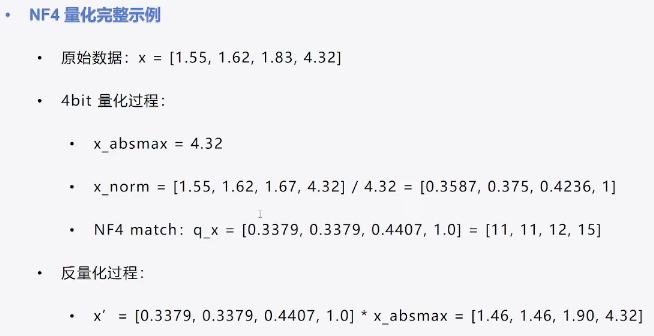

1、找出原始权重的最大值，即上图中的x_absmax。  
2、将原始权重除以最大值，归一化到[-1, 1]之间，即上图中的x_norm。  
3、看x_norm的每一个值对应哪个分位数，更准确地说是看x_norm的每一个值在哪个分位数区间，就得到应用的量化值。例如，权重值0.3587对应分位数0.3379的区间，所以其量化值为11。权重值0.4236对应分位数0.4407的区间，所以其量化值为12。  

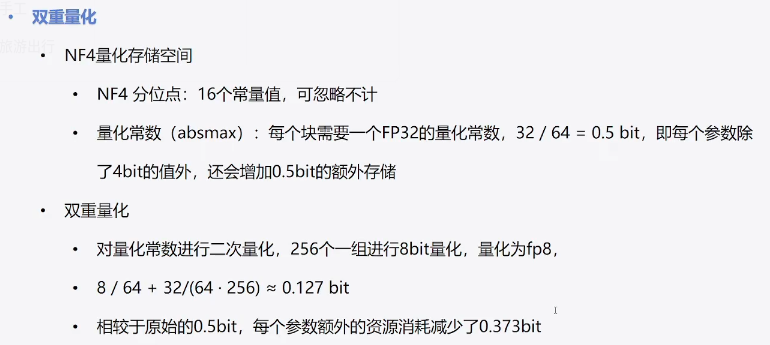

由于NF4量化采用分块量化，每64个权重为一个块进行量化，这样一来，每一块都要保存一个FP32量化常数absmax，32/64=0.5bit，相当于每个权重需要的存储空间是4+0.5bit。  

双重量化就是对量化常数absmax再进行一次INT8量化。每256个量化常数为一组，进行INT8量化。经过双重量化，相当于每个权重需要的存储空间是4+0.127bit。

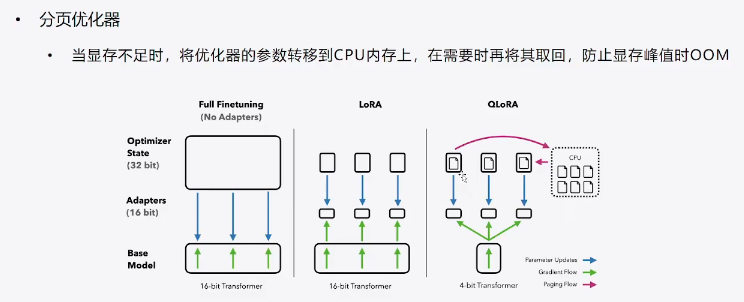